In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

import list_maps_plots

Original Dr. Will Jupyter notebook
https://github.com/will-henney/lvm-turbulence/blob/main/lvm-tarantula-explore-122.ipynb

#  Data

In [3]:
line        = r'H$\alpha$'
lambda_rest = 6562.8
line_id     = 'H'
line_id2   = "6563"

In [4]:
#line        = r'[O II] $\lambda$3726'
#lambda_rest = 3726.03 
#line_id     = 'OIIb'
#line_id2   = "3726"

In [5]:
#line        = r'[O II] $\lambda$3729'
#lambda_rest = 3728.80 
#line_id     = 'OIIa'
#line_id2   = "3729"

In [6]:
#line        = r'[O III]$\lambda$ 5007'
#lambda_rest = 5006.9
#line_id     = 'OIIIa'
#line_id2   = "5007"

In [7]:
# Data from observations
bins        = 0

region     = 'NGC 2070'
name_reg   = '30 Doradus'
reg_id     = '30Dor'
inst       = 'LVM'
inst_id    = 'LVM'
type_obj   = 'H II region'

pix        = 0   # Instrument resolution [arcsec/pix]
dist       = 50000 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60)
s0         = (s0_*pc)

#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + line_id2 
name_id      =  inst_id + '-' + reg_id + '-' + line_id2 + '_subrot'
print(name_file)
print(name_id)


LVM-30Dor-6563
LVM-30Dor-6563_subrot


In [8]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line = pd.DataFrame(_data['data'])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']
#_line = _line[0:3500]

In [9]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [10]:
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [11]:
ra0  = c0.ra.deg
dec0 = c0.dec.deg
#ra0 = _line["RAdeg"].median()
#dec0 = _line["DEdeg"].median()
print(ra0, dec0)

84.675 -69.1


In [12]:
from astropy.coordinates import SkyCoord
import astropy.units as u

centro = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg, frame='icrs')

coords = SkyCoord(
    ra=_line["RAdeg"].values * u.deg,
    dec=_line["DEdeg"].values * u.deg,
    frame='icrs'
)

radio = 1652/2 * u.arcsec   
sep = coords.separation(centro)

line_rad = _line[sep <= radio]


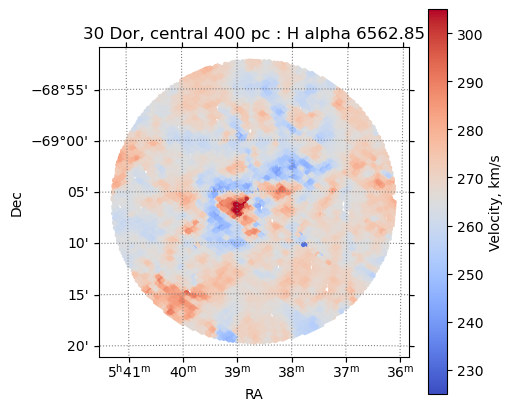

In [13]:
fig, ax = plt.subplots(
    figsize = (5,5),
    subplot_kw=dict(projection=wcs)
)

        
scat = ax.scatter(line_rad.RAdeg, 
           line_rad.DEdeg,
           s= 5,
           c = line_rad.V_mean,
           cmap="coolwarm",
           vmin=225,
           vmax=305,
           transform=ax.get_transform("world")
          )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"30 Dor, central 400 pc : H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")

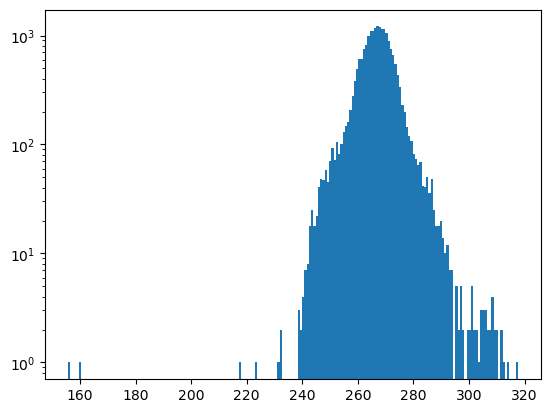

In [14]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"] , bins=200)
ax.set_yscale("log")

In [15]:
mu = line_rad["V_mean"].mean()
sigma = line_rad["V_mean"].std()
n = 3.0

#line_mask = line_rad[np.log10(line_rad["log_F"]) > 0.5]
#line_mask = line_rad[(line_rad["log_F"] > 1000) 
#     & (line_rad["V_mean"] > (mu - n*sigma)) & (line_rad["V_mean"] < (mu + n*sigma))]
mask = (line_rad["V_mean"] > 220) & (line_rad["V_mean"]<330) & (line_rad["log_F"] > 100) 
#mask = (line_rad["V_mean"] > 240) & (line_rad["V_mean"]<310) & (line_rad["log_F"] > 100) 

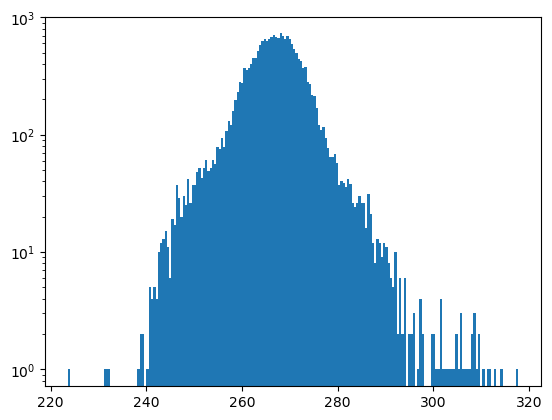

In [16]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"][mask] , bins=200)
ax.set_yscale("log")

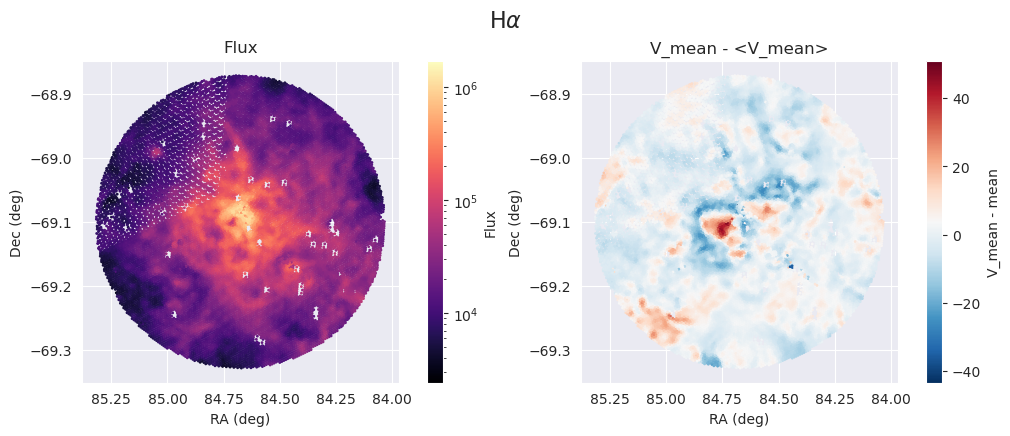

In [17]:
fig, ax = list_maps_plots.plot_panels_log_title(line_rad[mask],
                                                 s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=line)
plt.show()
#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

In [18]:
import lmc_model

In [19]:
df =  line_rad[mask]

In [20]:
c = SkyCoord(ra=df["RAdeg"].to_numpy() * u.deg, dec=df["DEdeg"].to_numpy() * u.deg)
c

<SkyCoord (ICRS): (ra, dec) in deg
    [(84.67528433, -69.325388  ), (84.70055662, -69.32023239),
     (84.72572852, -69.31507313), ..., (85.23962216, -69.15173025),
     (85.26594831, -69.15602515), (85.29228481, -69.16031603)]>

In [21]:
df.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma
count,20746.000000,20746.000000,20746.000000,2.074600e+04,20746.000000
mean,84.681062,-69.096233,266.929611,5.392637e+04,0.813004
std,0.320426,0.113288,6.996529,9.714836e+04,0.088444
min,84.032926,-69.329018,223.539100,2.420962e+03,0.338400
25%,84.424346,-69.186259,263.206625,1.249807e+04,0.757925
50%,84.693349,-69.096219,267.046750,2.448011e+04,0.795400
75%,84.937520,-69.005431,270.693350,5.169760e+04,0.845000
max,85.317236,-68.870945,317.811500,1.710726e+06,2.187500


In [22]:
vmod = lmc_model.vmodel_lmc(c)
vmod

<Quantity [268.49018305, 268.54637434, 268.60257936, ..., 270.16951146,
           270.16308705, 270.15670125] km / s>

In [23]:
df.insert(
    loc=5,
    column="v_mod",
    value=vmod.value,
)


In [24]:
col = df.pop('V_mean')
df.insert(4, 'v_', col)

In [25]:
df.insert(
    loc=2,
    column="V_mean",
    value= df.v_-df.v_mod,
)

In [26]:
df.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma,v_,v_mod
count,20746.000000,20746.000000,20746.000000,2.074600e+04,20746.000000,20746.000000,20746.000000
mean,84.681062,-69.096233,-3.130492,5.392637e+04,0.813004,266.929611,270.060103
std,0.320426,0.113288,7.147537,9.714836e+04,0.088444,6.996529,0.833100
min,84.032926,-69.329018,-46.670257,2.420962e+03,0.338400,223.539100,268.371644
25%,84.424346,-69.186259,-7.083951,1.249807e+04,0.757925,263.206625,269.387457
50%,84.693349,-69.096219,-2.905162,2.448011e+04,0.795400,267.046750,270.085434
75%,84.937520,-69.005431,0.795359,5.169760e+04,0.845000,270.693350,270.725452
max,85.317236,-68.870945,47.760732,1.710726e+06,2.187500,317.811500,271.703626


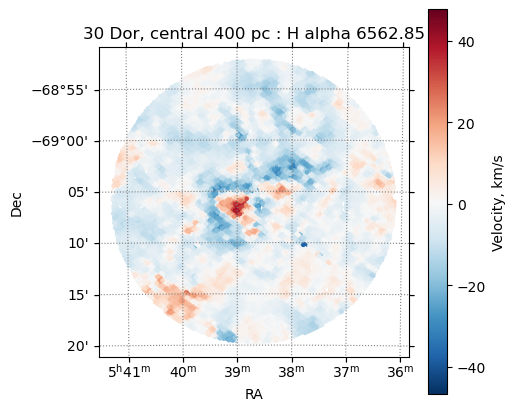

In [27]:
fig, ax = plt.subplots(
    figsize = (5,5),
    subplot_kw=dict(projection=wcs)
)

        
scat = ax.scatter(df.RAdeg, 
           df.DEdeg,
           s= 5,
           c = df.v_-df.v_mod,
           cmap="RdBu_r",
 #          vmin=225,
 #          vmax=305,
           transform=ax.get_transform("world")
          )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"30 Dor, central 400 pc : H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")

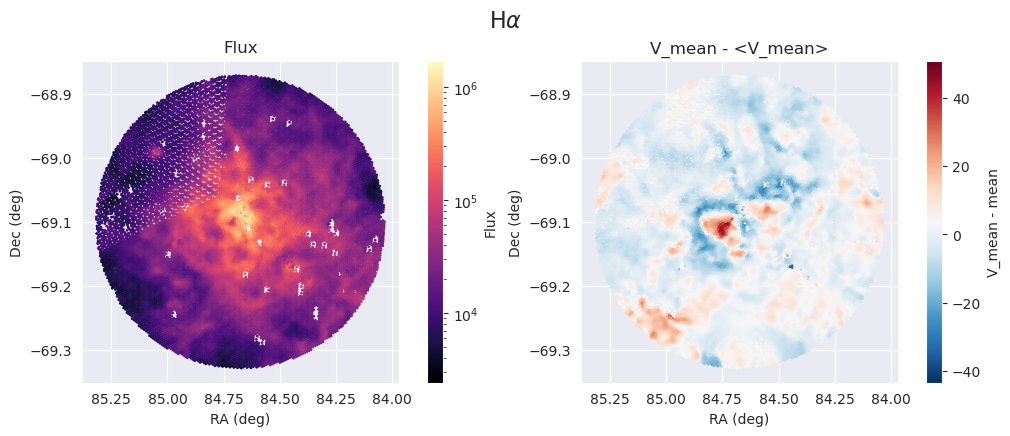

<Figure size 640x480 with 0 Axes>

In [28]:
fig, ax = list_maps_plots.plot_panels_log_title(df,
                                                 s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=line)
plt.show()
plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

# Export Data

In [ ]:
N = np.sqrt((df.RAdeg.max()-df.RAdeg.min())*(df.DEdeg.max()-df.DEdeg.min())) * pc * 3600
sig       = df['V_mean'].std()

In [ ]:
t         = Table.from_pandas(df.reset_index(drop=True))
table_hdu = fits.BinTableHDU(t, name=name_id)

In [ ]:
primary = fits.PrimaryHDU()
primary.header["NAME_ID"]    = (name_id, "pipeline identifier")
primary.header["FILE"]       = (name_file, "Fits file name")
primary.header["REG"]        = (region, "Region catalog name")
primary.header["NAME_REG"]   = (name_reg, "Region name")
primary.header["REG_ID"]     = (reg_id, "Region identifier")
primary.header["TYPE_OBJ"]   = (type_obj, "Type object")
primary.header["DIST"]       = (dist, "Distance in parsecs")
primary.header["INSTR"]      = (inst, "Instrument")
primary.header["LINE"]       = (line, "Emission line name")
primary.header["LINE_ID"]    = (line_id, "Emission line identifier")
primary.header["L_REST"]= (lambda_rest, "Emission line name")
primary.header["SIG"]        = (sig, "Standard deviation vel map")
primary.header["SIG2"]       = (sig**2, "Vel Variance map")
primary.header["S0"]         = (s0, "Atmospheric seeing")
primary.header["BOX_SIZE"]   = (N, "Observational box_size")
primary.header["PC"]         = (pc, "parsec convertion")
primary.header["PIX"]        = (pix, "Instrument pixel scale")
primary.header["BINSIZE"]    = (bins, "Spatial binning factor")
#hdr["noise"]     = (noise, "Instrumental noise")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")
primary.header["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")

In [ ]:
with fits.open("fits_ready/" + name_id + ".fits") as hdul:
    hdul.info()